# 01 · Exploratory Data Analysis

**Goal.** Understand every corpus we are about to train on, and quantify the one
thing that decides whether this project can work: how far the Ekegusii data
(Bible) is from the target domain (public service announcements).

**Inputs**
- `data/bible_en_guz_swh.csv` — English · Ekegusii · Kiswahili triples
- `data/lughayangu_sentences.csv` — contemporary English · Ekegusii pairs
- `psa_parallel_dataset.csv` — the 4-way PSA corpus *(optional, external: set `CORPUS_GENERATION_DATA`)*
- `english_psas.csv` — the English PSA seed set *(optional, external)*

**Outputs** — figures in `artifacts/figures/`, a summary in
`artifacts/data/eda_summary.json`

**Runtime** — about 2 minutes, CPU only.

In [16]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # so `import nb_common` works
sys.path.insert(0, str(pathlib.Path.cwd()))
import nb_common as C

C.set_seed()
C.use_house_style()
print(f"project root: {C.ROOT}")

project root: /home/jovyan/public-service-anouncement-MT


In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from collections import Counter
import re

C.banner("Checking inputs")
C.require_files(C.BIBLE_CSV)
HAS_LUGHAYANGU = C.LUGHAYANGU_CSV.exists()
print(f"  {'ok ' if HAS_LUGHAYANGU else 'absent'} lughayangu_sentences.csv (optional)")

# The synthetic English corpus and its 4-way translation come from a separate
# project that is not in this repository. Set CORPUS_GENERATION_DATA to its data
# folder to get the register-comparison figures; without it this notebook still
# runs and simply skips them.
HAS_GEN = C.PSA_PARALLEL_CSV.exists() and C.ENGLISH_PSA_CSV.exists()
print(f"  {'ok ' if HAS_GEN else 'absent'} psa_parallel_dataset.csv / english_psas.csv (optional, external)")
if not HAS_GEN:
    print(f"         looked in {C.GEN_INPUTS}")

## 1. Load everything

In [18]:
bible = pd.read_csv(C.BIBLE_CSV)
psa   = pd.read_csv(C.PSA_PARALLEL_CSV) if HAS_GEN else pd.DataFrame()
lugha = pd.read_csv(C.LUGHAYANGU_CSV) if HAS_LUGHAYANGU else pd.DataFrame()

print(f"bible triples        : {len(bible):,}   columns: {list(bible.columns)[:6]}")
print(f"PSA parallel records : {len(psa):,}")
print(f"lughayangu pairs     : {len(lugha):,}")
bible.head(3)

bible triples        : 30,863   columns: ['ref', 'book', 'chapter', 'verse', 'english', 'ekegusii']
PSA parallel records : 50,317
lughayangu pairs     : 316


,ref,book,chapter,verse,english,ekegusii,swahili,source,eng_words,eke_words,swa_words,story_id,page,needs_review
0,1CH 10:1,1CH,10.0,1.0,"Now the Philistines fought against Israel, and...","Bono Abafirisiti bakarwania Abaisraeli, na Aba...",Basi Wafilisti wakapigana na Israeli. Waisrael...,bible_ebible,21.0,16.0,13.0,NaN,NaN,NaN
1,1CH 10:10,1CH,10.0,10.0,They put his armor in the temple of their gods...,Bakabeeka ebirwanero biaye ime ase Hekalu ye c...,Waliweka silaha zake katika hekalu la miungu y...,bible_ebible,26.0,17.0,15.0,NaN,NaN,NaN
2,1CH 10:11,1CH,10.0,11.0,When the people of Jabesh-gilead heard about e...,Korende ekero abanto bonsi ba Yabeshi o Gilead...,Wakazi wote wa Yabeshi-Gileadi waliposikia yot...,bible_ebible,14.0,14.0,9.0,NaN,NaN,NaN


## 2. Integrity: nulls, blanks, duplicates

Anything found here becomes a silent training bug later, so check before
modelling rather than after a confusing loss curve.

In [19]:
def integrity(df, cols, label):
    rows = []
    for c in cols:
        if c not in df.columns:
            continue
        s = df[c].astype(str)
        rows.append({
            "column": c,
            "null": int(df[c].isna().sum()),
            "blank": int((s.str.strip() == "").sum()),
            "duplicated": int(s.duplicated().sum()),
            "mean_words": round(s.str.split().str.len().mean(), 1),
        })
    out = pd.DataFrame(rows)
    print(f"\n--- {label} ---")
    print(out.to_string(index=False))
    return out

integrity(bible, ["english", "ekegusii", "swahili"], "Bible triples")
integrity(psa, ["English", "Kiswahili", "Somali", "Luo"], "PSA parallel")
if HAS_LUGHAYANGU:
    integrity(lugha, ["english", "ekegusii"], "lughayangu")


--- Bible triples ---
  column  null  blank  duplicated  mean_words
 english     0      0         416        23.8
ekegusii     0      0          83        19.7
 swahili     0      0         315        19.4

--- PSA parallel ---
   column  null  blank  duplicated  mean_words
  English     0      0         196        19.9
Kiswahili     0      0        1893        22.4
   Somali     0     38         396        24.3
      Luo     3     32         697        25.6

--- lughayangu ---
  column  null  blank  duplicated  mean_words
 english     0      0           1         7.8
ekegusii     0      0           0         5.1


## 3. Sentence length by corpus and language

Length drives `max_length` and therefore memory. It also exposes alignment
problems: if the Ekegusii side is systematically far longer or shorter than the
English side, some rows are misaligned.

saved figure -> /home/jovyan/public-service-anouncement-MT/artifacts/figures/01_length_distributions.png


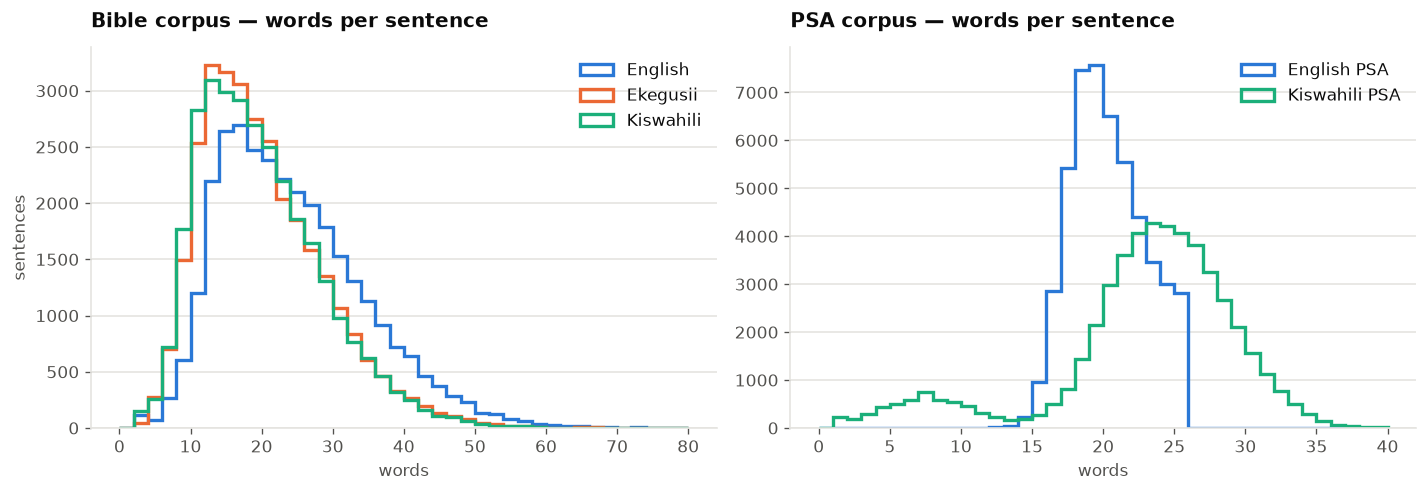


Bible  English  p50/p95/max: [22. 43.] 226
PSA    English  p50/p95/max: [20. 25.] 25


In [20]:
def wl(s): return s.astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
for i, (col, name) in enumerate([("english", "English"), ("ekegusii", "Ekegusii"),
                                 ("swahili", "Kiswahili")]):
    ax.hist(wl(bible[col]), bins=range(0, 81, 2), histtype="step", linewidth=2,
            color=C.LANG_COLOR[col], label=name)
ax.set_title("Bible corpus — words per sentence")
ax.set_xlabel("words"); ax.set_ylabel("sentences"); ax.legend()

ax = axes[1]
ax.hist(wl(psa["English"]), bins=range(0, 41, 1), histtype="step", linewidth=2,
        color=C.LANG_COLOR["english"], label="English PSA")
ax.hist(wl(psa["Kiswahili"].fillna("")), bins=range(0, 41, 1), histtype="step",
        linewidth=2, color=C.LANG_COLOR["swahili"], label="Kiswahili PSA")
ax.set_title("PSA corpus — words per sentence")
ax.set_xlabel("words"); ax.legend()

plt.tight_layout(); C.save_fig(fig, "01_length_distributions"); plt.show()

print("\nBible  English  p50/p95/max:", np.percentile(wl(bible.english), [50, 95]).round(0), wl(bible.english).max())
print("PSA    English  p50/p95/max:", np.percentile(wl(psa.English), [50, 95]).round(0), wl(psa.English).max())

### Length-ratio check

For a correctly aligned pair, the Ekegusii/English word ratio should cluster
tightly. A long tail means residual misalignment.

saved figure -> /home/jovyan/public-service-anouncement-MT/artifacts/figures/01_length_ratio.png


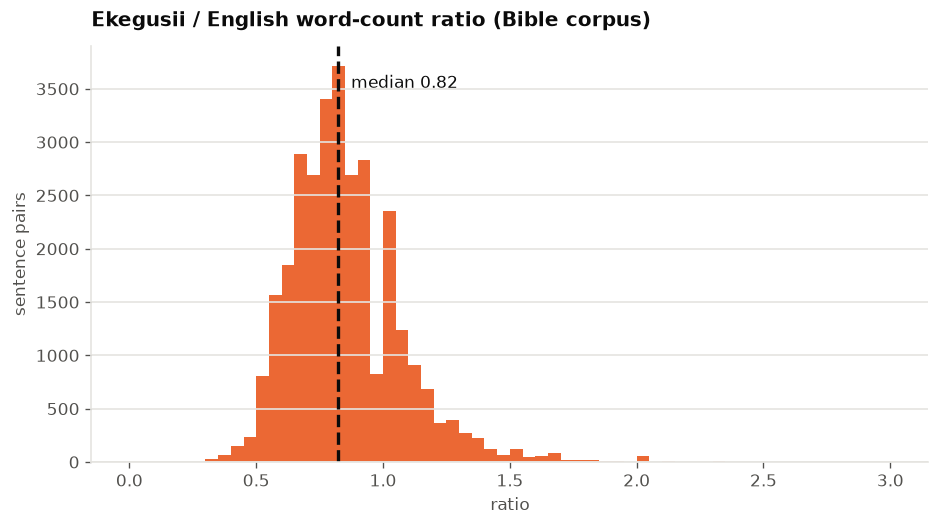

pairs with ratio outside 0.4–2.5: 114


In [21]:
ratio = wl(bible.ekegusii) / wl(bible.english).clip(lower=1)
fig, ax = plt.subplots()
ax.hist(ratio, bins=np.arange(0, 3.05, 0.05), color=C.PALETTE[1])
ax.axvline(ratio.median(), color=C.INK, linewidth=2, linestyle="--")
ax.annotate(f"median {ratio.median():.2f}", (ratio.median(), ax.get_ylim()[1]*0.9),
            xytext=(8, 0), textcoords="offset points", color=C.INK)
ax.set_title("Ekegusii / English word-count ratio (Bible corpus)")
ax.set_xlabel("ratio"); ax.set_ylabel("sentence pairs")
C.save_fig(fig, "01_length_ratio"); plt.show()
print(f"pairs with ratio outside 0.4–2.5: {int(((ratio<0.4)|(ratio>2.5)).sum())}")

## 4. Domain balance in the PSA corpus

The balancing controller was supposed to produce a uniform spread across the
five domains. Verify it did — an imbalance here propagates straight into what
the fine-tuned model is good at.

saved figure -> /home/jovyan/public-service-anouncement-MT/artifacts/figures/01_domain_balance.png


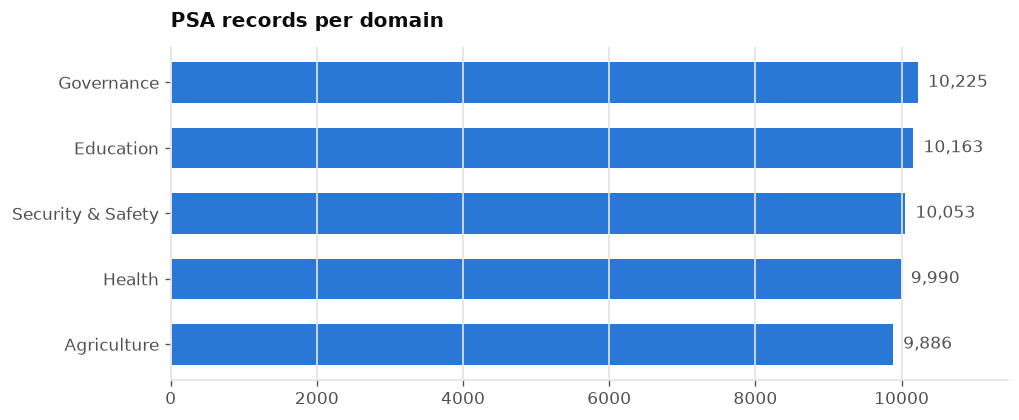

Domain
Governance           10225
Education            10163
Security & Safety    10053
Health                9990
Agriculture           9886

imbalance (max/min): 1.03x


In [22]:
if "Domain" in psa.columns:
    counts = psa["Domain"].value_counts()
    fig, ax = plt.subplots(figsize=(9, 3.6))
    bars = ax.barh(counts.index[::-1], counts.values[::-1], color=C.PALETTE[0], height=0.62)
    for b, v in zip(bars, counts.values[::-1]):
        ax.annotate(f"{v:,}", (v, b.get_y() + b.get_height()/2), xytext=(6, 0),
                    textcoords="offset points", va="center", color=C.INK_MUTED)
    ax.set_title("PSA records per domain")
    ax.grid(axis="x"); ax.grid(axis="y", visible=False)
    ax.set_xlim(0, counts.max() * 1.12)
    C.save_fig(fig, "01_domain_balance"); plt.show()
    print(counts.to_string())
    print(f"\nimbalance (max/min): {counts.max()/counts.min():.2f}x")

## 5. The register gap — the number that matters most

Our Ekegusii data is scripture. Our target is public service announcements.
Measure the distance directly: **how much PSA vocabulary has the model never
seen in any aligned sentence?**

Every English content word absent from the aligned Bible corpus is a word for
which no Ekegusii equivalent was ever demonstrated.

In [23]:
STOP = set("""the a an and or but if of to in on at for your you we they it is are was were
be been being have has had do does did will would shall should can could may might must not
no this that these those with from by as all any more most very so than then into out up down
over under about after before because their our its his her""".split())

def content_words(series):
    c = Counter()
    for t in series.astype(str):
        c.update(w for w in re.findall(r"[a-z']+", t.lower())
                 if w not in STOP and len(w) > 2)
    return c

psa_vocab = content_words(psa["English"])
bib_vocab = content_words(bible["english"])

missing = {w: n for w, n in psa_vocab.items() if w not in bib_vocab}
tok_total = sum(psa_vocab.values()); tok_missing = sum(missing.values())

print(f"PSA content-word types            : {len(psa_vocab):,}")
print(f"  never seen in the Bible corpus  : {len(missing):,} "
      f"({100*len(missing)/len(psa_vocab):.1f}% of types)")
print(f"  as a share of PSA tokens        : {100*tok_missing/tok_total:.1f}%")

PSA content-word types            : 5,837
  never seen in the Bible corpus  : 3,110 (53.3% of types)
  as a share of PSA tokens        : 42.2%


saved figure -> /home/jovyan/public-service-anouncement-MT/artifacts/figures/01_vocabulary_gap.png


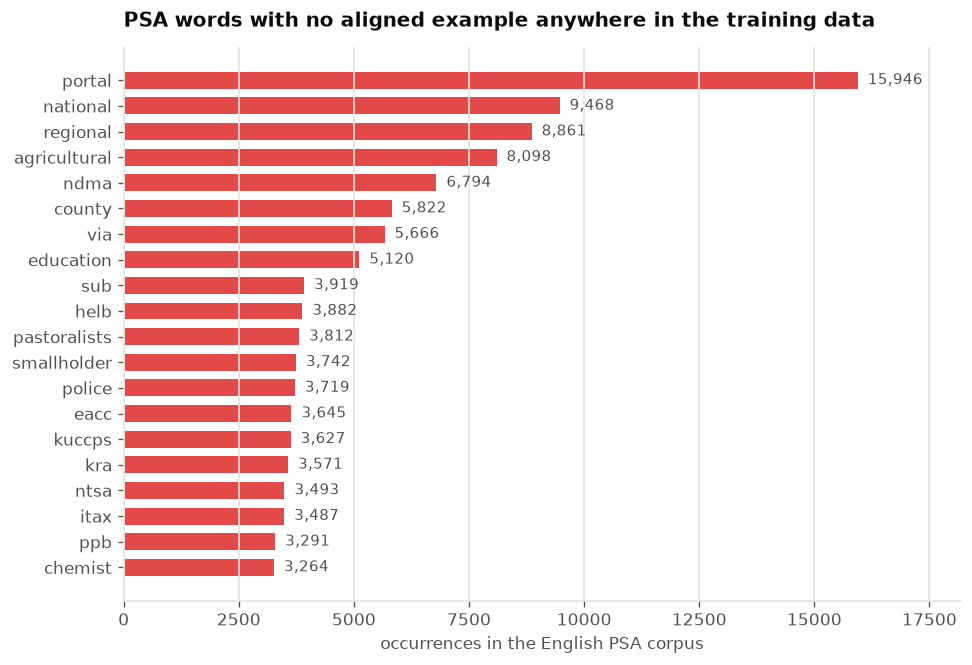

In [24]:
top = sorted(missing.items(), key=lambda kv: -kv[1])[:20]
words = [w for w, _ in top][::-1]; vals = [n for _, n in top][::-1]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(words, vals, color=C.PALETTE[7], height=0.66)
for b, v in zip(bars, vals):
    ax.annotate(f"{v:,}", (v, b.get_y() + b.get_height()/2), xytext=(6, 0),
                textcoords="offset points", va="center", color=C.INK_MUTED, fontsize=9)
ax.set_title("PSA words with no aligned example anywhere in the training data")
ax.set_xlabel("occurrences in the English PSA corpus")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_xlim(0, max(vals) * 1.14)
C.save_fig(fig, "01_vocabulary_gap"); plt.show()

> **Read this figure carefully.** These are institutions, portals and civic terms
> that dominate Kenyan PSAs and appear nowhere in scripture. The model will have
> to translate them having never seen an Ekegusii equivalent. This is the single
> biggest risk to the project.
>
> The original plan was to co-train the 50k Kiswahili PSA corpus, so the shared
> decoder could pick up PSA register from the Kiswahili side. **That plan was
> dropped.** Those Kiswahili targets were themselves NLLB-600M output, so
> training a 600M model on them would have been self-distillation rather than
> learning. The gap is closed instead by the professor-supplied Ekegusii PSA
> corpus in stage 2 — which is the reason stage 2 exists at all.

## 6. Type/token statistics per language

In [25]:
rows = []
for label, series in [("Bible EN", bible.english), ("Bible GUZ", bible.ekegusii),
                      ("Bible SWH", bible.swahili), ("PSA EN", psa.English),
                      ("PSA SWH", psa.Kiswahili.fillna(""))]:
    toks = [w for t in series.astype(str) for w in re.findall(r"[\w']+", t.lower())]
    types = len(set(toks))
    rows.append({"corpus": label, "tokens": len(toks), "types": types,
                 "type/token": round(types/max(1, len(toks)), 4)})
stats = pd.DataFrame(rows)
print(stats.to_string(index=False))
print("\nEkegusii has far more types per token than English — agglutinative")
print("morphology. Expect higher subword fertility (measured in notebook 03).")

   corpus  tokens  types  type/token
 Bible EN  743138  14361      0.0193
Bible GUZ  659694  45084      0.0683
Bible SWH  600558  46403      0.0773
   PSA EN 1007293   6211      0.0062
  PSA SWH 1128751   8775      0.0078

Ekegusii has far more types per token than English — agglutinative
morphology. Expect higher subword fertility (measured in notebook 04).


## 7. Save the summary

In [26]:
C.save_json({
    "bible_triples": int(len(bible)),
    "psa_records": int(len(psa)),
    "lughayangu_pairs": int(len(lugha)),
    "psa_vocab_types": len(psa_vocab),
    "psa_vocab_unseen_in_bible": len(missing),
    "psa_unseen_token_share": round(tok_missing / tok_total, 4),
    "bible_len_ratio_median": round(float(ratio.median()), 3),
    "type_token": stats.to_dict("records"),
}, C.DATA / "eda_summary.json")
print("\nNext: 02_build_training_data.ipynb")


wrote /home/jovyan/public-service-anouncement-MT/artifacts/data/eda_summary.json

Next: 02_retranslate_swahili.ipynb
